<a href="https://colab.research.google.com/github/arpanbiswas52/papers-code-pcEGP/blob/main/data/pc_EGP_1D_DMRG(Notebook).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook for the paper "Physically Constrained Ensemble Gaussian Process Modelling for Expensive Quantum Systems with Heteroskedastic Noise"

- Application on DMRG simulations of the Bose-Hubbard Model to predict the critical interaction parameter U_c governing the superfluid-to-Mott-insulator transition.

- Here, we consider a 1D parameter space of interaction parameter U_c and the function space (1-ζ)^2 where the physical constraint on the density is (1-ζ)^2≥0.

- Code and notebook prepared by Arpan Biswas

- Data provided by Matthias Thamm






Install Packages

In [ ]:
!pip install botorch #version 0.5.0
!pip install gpytorch #version 1.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 25.4 MB/s eta 0:00:00


Import functions

In [ ]:
#Import classical numpy and torch
import torch as to
import numpy as np
#Plotting
import matplotlib.pyplot as plt
import matplotlib.cm as cm
#Random # generator
import random

# Import GP and BoTorch functions
import gpytorch as gpt
from botorch.models import SingleTaskGP, ModelListGP
from botorch.models.gpytorch import GPyTorchModel
from botorch.utils import standardize
#from botorch import fit_gpytorch_model
from gpytorch.distributions import MultivariateNormal
from gpytorch.kernels import ScaleKernel, RBFKernel, MaternKernel, ConstantKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ConstantMean
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.acquisition import ExpectedImprovement
from botorch.sampling import IIDNormalSampler
from gpytorch.likelihoods.likelihood import Likelihood
from gpytorch.constraints import GreaterThan
from gpytorch.models import ExactGP


#Import optimizer algorithm to train GP hyperparameters
from torch.optim import SGD
from torch.optim import Adam

#other math functions
from scipy.stats import norm
from scipy.special import roots_hermite






In [ ]:
#########################Gaussian Process########################
class SimpleCustomGP(ExactGP, GPyTorchModel):
    _num_outputs = 1  # to inform GPyTorchModel API

    def __init__(self, train_X, train_Y):
        # squeeze output dim before passing train_Y to ExactGP
        super().__init__(train_X, train_Y.squeeze(-1), GaussianLikelihood())
        ## Here we use constant mean, user can change here with different mean function
        self.mean_module = ConstantMean()
        #self.mean_module = LinearMean(train_X.shape[-1])
        ## Here we use Radial Basis function kernel, user can change here with different kernel function
        self.covar_module = ScaleKernel(
            base_kernel=MaternKernel(nu=1.5, ard_num_dims=train_X.shape[-1]),
        )
        self.to(train_X)  # make sure we're on the right device/dtype

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)

############## Optimize Hyperparameters of GP##############################
def optimize_hyperparam_trainGP(train_X, train_Y):
    # Gp model fit
    gp_surro = SimpleCustomGP(train_X, train_Y)
    gp_surro = gp_surro.double()
    gp_surro.likelihood.noise_covar.register_constraint("raw_noise", GreaterThan(0.0166))

    gp_surro.train()
    gp_surro.likelihood.train()
    ## Here we use Adam optimizer with learning rate =0.2, user can change here with different algorithm and/or learning rate
    optimizer = Adam([{'params': gp_surro.parameters()}], lr=0.2)

    mll = ExactMarginalLogLikelihood(gp_surro.likelihood, gp_surro)
    mll = mll.to(train_X)
    NUM_EPOCHS = 150

    for epoch in range(NUM_EPOCHS):
        # clear gradients
        optimizer.zero_grad()
        # forward pass through the model to obtain the output MultivariateNormal
        output = gp_surro(train_X)
        # Compute negative marginal log likelihood
        loss = - mll(output, train_Y.squeeze(-1))
        # back prop gradients
        loss.backward()
        # print last iterations
        if (epoch + 1) > NUM_EPOCHS:
            print("GP Model trained:")
            print("Iteration:" + str(epoch + 1))
            print("Loss:" + str(loss.item()))
            # print("Length Scale:" +str(gp_PZO.covar_module.base_kernel.lengthscale.item()))
            print("noise:" + str(gp_surro.likelihood.noise.item()))

        optimizer.step()


    return gp_surro

In [ ]:
##########Plotting functions#########################################
def plot_exploration_results_vanila(ground_truth, qMC, y_pred_means, y_pred_vars, train_X, train_Y, acq_val, maxacq_val, iter):
    y_pred_sd = np.sqrt(y_pred_vars)
    Y_pred_upper = y_pred_means+(2*y_pred_sd)
    Y_pred_lower = y_pred_means-(2*y_pred_sd)
    old_X = train_X[:-1].detach().numpy()
    old_Y = train_Y[:-1, 0].detach().numpy()
    new_X = train_X[-1].detach().numpy()
    new_Y = train_Y[-1, 0].detach().numpy()
    y_sd = qMC[:, 2]*10**4
    y_mean = qMC[:, 1]*10**4
    y_upper = y_mean+(2*y_sd)
    y_lower = y_mean-(2*y_sd)
    fig, ax = plt.subplots(2, 1, figsize=(5, 10))
    #Plotting for BO exploration in GP predicted function
    ax[0].plot(qMC[:, 0],y_mean, c='gray', linewidth=2, label="qMC")
    ax[0].plot(qMC[:, 0],y_upper, c='gray', linestyle = '--', linewidth=2, label="qMC+2std")
    ax[0].plot(qMC[:, 0],y_lower, c='gray', linestyle = '--', linewidth=2, label="qMC-2std")
    ax[0].plot(ground_truth[:, 0], ground_truth[:, 1]*10**4, c="r", marker="X", label="ground truth")
    #ax[0].plot(qMC[:, 0], qMC[:, 1], c="b", label = "qMC")

    ax[0].plot(qMC[:, 0], y_pred_means.detach().numpy(), c='blue', linewidth=2, label="GP")
    ax[0].plot(qMC[:, 0], Y_pred_upper.detach().numpy(), c='blue',linestyle = '--', linewidth=2, label="GP+2std")
    ax[0].plot(qMC[:, 0], Y_pred_lower.detach().numpy(), c='blue',linestyle = '--', linewidth=2, label="GP-2std")

    ax[0].scatter(old_X, old_Y, c='g', marker='o')
    ax[0].scatter(new_X, new_Y, c='black', marker='X')
    ax[0].set_xlabel("r")
    ax[0].set_ylabel("rho")
    ax[0].legend(loc="best")
    ax[0].set_title("iter=" + str(iter))


    #Plotting for BO exploration in acquistion function
    ax[1].plot(X, acq_val, c='blue', linewidth=2)
    ax[1].scatter(new_X, maxacq_val, c='black', marker='X')
    #ax[1].legend(loc="best")
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('acq. func. value')
    #plt.savefig(str(i-1) + '.png')
    #ax[1].set_title("iter=" + str(iter))
    plt.show()


In [ ]:
########## BO acquisition function ###########################
def acqmanEI(y_pred_means, y_pred_vars, train_Y, ieval, opt="max"):
    if (opt == "min"):
        y_pred_means = -y_pred_means
        train_Y = -train_Y

    y_pred_means = y_pred_means.detach().numpy()
    y_pred_vars = y_pred_vars.detach().numpy()
    fmax = train_Y.max()
    fmax = fmax.detach().numpy()
    best_value = fmax
    EI_val = np.zeros(len(y_pred_vars))
    Z = np.zeros(len(y_pred_vars))
    eta = 0.01
    for i in range(0, len(y_pred_vars)):
        if (y_pred_vars[i] <=0):
            EI_val[i] = 0
        else:
            Z[i] =  (y_pred_means[i]-best_value-eta)/np.sqrt(y_pred_vars[i])
            EI_val[i] = (y_pred_means[i]-best_value-eta)*norm.cdf(Z[i]) + np.sqrt(y_pred_vars[i])*norm.pdf(Z[i])

    EI_val[ieval] = 0
    acq_val = np.max(EI_val)
    acq_cand = [k for k, j in enumerate(EI_val) if j == acq_val]

    return acq_cand, acq_val, EI_val

def acqmanPI(y_pred_means, y_pred_vars, train_Y, ieval, opt="max"):
    if (opt == "min"):
        y_pred_means = -y_pred_means
        train_Y = -train_Y


    y_pred_means = y_pred_means.detach().numpy()
    y_pred_vars = y_pred_vars.detach().numpy()
    fmax = train_Y.max()
    fmax = fmax.detach().numpy()
    best_value = fmax
    PI_val = np.zeros(len(y_pred_vars))
    Z = np.zeros(len(y_pred_vars))
    eta = 0.01
    for i in range(0, len(y_pred_vars)):
        if (y_pred_vars[i] <=0):
            PI_val[i] = 0
        else:
            Z[i] =  (y_pred_means[i]-best_value-eta)/np.sqrt(y_pred_vars[i])
            PI_val[i] = norm.cdf(Z[i])

    PI_val[ieval] = 0
    acq_val = np.max(PI_val)
    acq_cand = [k for k, j in enumerate(PI_val) if j == acq_val]
    return acq_cand, acq_val, PI_val



##########Plotting functions#########################################
def plot_exploration_results(X, true_y, y_pred_means_realization, weights, y_pred_means, y_pred_vars, train_X, train_Y, acq_val, maxacq_val, iter):
    y_pred_sd = np.sqrt(y_pred_vars)
    Y_pred_upper = y_pred_means+(1*y_pred_sd)
    Y_pred_lower = y_pred_means-(1*y_pred_sd)

    y_sd = np.std(true_y,axis =1)
    y_mean = np.mean(true_y, axis =1)
    y_upper = y_mean+(1*y_sd)
    y_lower = y_mean-(1*y_sd)

    old_X = train_X[:-1].detach().numpy()
    old_Y = torch.mean(train_Y[:-1], dim =1).detach().numpy()
    new_X = train_X[-1].detach().numpy()
    new_Y = torch.mean(train_Y[-1], dim=0).detach().numpy()
    weights = weights.detach().numpy()

    #cmap = cm.get_cmap('Reds', 5)
    # Normalize values for colormap mapping
    norm = plt.Normalize(vmin=np.min(weights), vmax=np.max(weights))
    cmap = cm.viridis  # Choose a colormap
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    #Plotting for BO exploration in GP realizations
    ax[0].plot(X,y_mean, c='gray', linewidth=2)
    #ax[0].plot(X,y_upper, c='gray', linestyle = '--', linewidth=2)
    #ax[0].plot(X,y_lower, c='gray', linestyle = '--', linewidth=2)
    #ax[0].plot(X, y_pred_means.detach().numpy(), c='blue', linewidth=2)
    #ax[0].plot(X, Y_pred_upper.detach().numpy(), c='blue',linestyle = '--', linewidth=2)
    #ax[0].plot(X, Y_pred_lower.detach().numpy(), c='blue',linestyle = '--', linewidth=2)
    for i in range(0, y_pred_means_realization.shape[1]):
      #color = cmap(i)
      color = cmap(norm(weights[i]))  # Map value to color
      #ax[0].plot(X, y_pred_means_realization[:, i].detach().numpy(), color=color, linewidth=2, label=f'w:{weights[i]:.2f}')
      ax[0].plot(X, y_pred_means_realization[:, i].detach().numpy(), color=color, linewidth=2)

    # Add colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])  # Required for colorbar in some matplotlib versions
    cbar = fig.colorbar(sm, ax=ax[0])
    cbar.set_label('Weight Value')
    ax[0].scatter(old_X, old_Y, c='red', marker='o')
    ax[0].scatter(new_X, new_Y, c='red', marker='o')
    #ax[0].legend(loc="best")
    ax[0].set_xlabel('X')
    ax[0].set_ylabel('Z')
    ax[0].set_title("iter=" + str(iter))


        #Plotting for BO exploration in GP predicted function
    ax[1].plot(X,y_mean, c='gray', linewidth=2)
    #ax[1].plot(X,y_upper, c='gray', linestyle = '--', linewidth=2)
    #ax[1].plot(X,y_lower, c='gray', linestyle = '--', linewidth=2)
    ax[1].plot(X, y_pred_means.detach().numpy(), c='blue', linewidth=2)
    ax[1].plot(X, Y_pred_upper.detach().numpy(), c='blue',linestyle = '--', linewidth=2)
    ax[1].plot(X, Y_pred_lower.detach().numpy(), c='blue',linestyle = '--', linewidth=2)
    #for i in range(0, y_pred_means_realization.shape[1]):
      #color = cmap(i)
    #  color = cmap(norm(weights[i]))  # Map value to color
      #ax[0].plot(X, y_pred_means_realization[:, i].detach().numpy(), color=color, linewidth=2, label=f'w:{weights[i]:.2f}')
    #  ax[0].plot(X, y_pred_means_realization[:, i].detach().numpy(), color=color, linewidth=2)

    # Add colorbar
    #sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    #sm.set_array([])  # Required for colorbar in some matplotlib versions
    #cbar = fig.colorbar(sm, ax=ax[0])
    #cbar.set_label('Weight Value')
    ax[1].scatter(old_X, old_Y, c='red', marker='o')
    ax[1].scatter(new_X, new_Y, c='red', marker='o')
    #ax[0].legend(loc="best")
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('Z')
    ax[1].set_title("iter=" + str(iter))

    #Plotting for BO exploration in acquistion function
    ax[2].plot(X, acq_val, c='blue', linewidth=2)
    ax[2].scatter(new_X, maxacq_val, c='black', marker='X')
    #ax[1].legend(loc="best")
    ax[2].set_xlabel('X')
    ax[2].set_ylabel('acq. func. value')
    #plt.savefig(str(i-1) + '.png')
    #ax[1].set_title("iter=" + str(iter))
    plt.show()





# Designing constrainted GP

1. $\mu(X_{U}) >= 0$ where $X_{U}$ are the unexplored locations
2. $||Y(X)-\mu(X)||=0$

In [ ]:
import scipy.stats as stats
def phy_loss (X_train, y_train, X_test, noise_variance, lengthscale, output_scale, w1, w2):
    # Constraint1: mean at test inputs should be >= 0

    R = 0.95 #95% Reliability
    xlim = 0
    means1, vars1 = predict(X_train, y_train, X_test, noise_variance, lengthscale, output_scale)
    means1 = means1[:, 0]
    sigma1 = torch.sqrt(vars1+1e-6) #1e-6 for numerical stability
    means1 = means1.detach().numpy()
    sigma1 = sigma1.detach().numpy()
    loss1 = 0
    j1 = 0
    means1_norm = (means1 - np.min(means1)) / ((np.max(means1) - np.min(means1)))

    probability = 1 - stats.norm.cdf(xlim, means1, sigma1) #Prob of X greater than 0
    #print(probability)
    for i in range(0, len(probability)):
        if (probability[i] < R):
            loss1 = loss1 + means1_norm[i]
            j1 = j1 + 1
    loss1 = loss1/(j1+1)
    loss1 = w1*loss1
    #print(j1)
    #print(loss1)
    #loss1 = -torch.sum(torch.clamp(means1, max=0))

    # Constraint2: deviation between predicted and true value of current X samples
    means2, vars2 = predict(X_train, y_train, X_train, noise_variance, lengthscale, output_scale)
    means2 = means2[:, 0]
    y_train = y_train[:, 0]
    means2 = means2.detach().numpy()
    y_train = y_train.detach().numpy()
    means2_norm = (means2 - np.min(means2)) / ((np.max(means2) - np.min(means2)))
    y_train_norm = (y_train - np.min(y_train)) / ((np.max(y_train) - np.min(y_train)))
    #print(y_train_norm.shape, means2_norm.shape)
    loss2 = (np.sum(np.absolute(y_train_norm - means2_norm)))/(len(y_train_norm))
    loss2 = w2*loss2
    #print(loss2)

    loss = loss1 + loss2
    loss = torch.tensor(loss)
    #print(100*loss)

    return loss

In [ ]:
import torch
import torch.optim as optim
import math

# 1. Define the RBF kernel
def rbf_kernel(x1, x2, lengthscale, output_scale):
    distance = torch.cdist(x1, x2, p=2)
    return output_scale * torch.exp(-0.5 * (distance / lengthscale)**2)




# 1. Define the Matern kernel
def matern_kernel(x1, x2, nu, lengthscale, output_scale):
    """
    Computes the Matern kernel between two sets of inputs.

    Args:
        x1 (torch.Tensor): Input tensor of shape (n1, d).
        x2 (torch.Tensor): Input tensor of shape (n2, d).
        nu (float): Smoothness parameter (0.5, 1.5, or 2.5).
        lengthscale (float): Lengthscale parameter.

    Returns:
        torch.Tensor: Kernel matrix of shape (n1, n2).
    """

    distance = torch.cdist(x1 / lengthscale, x2 / lengthscale)

    if nu == 0.5:
        return output_scale * torch.exp(-distance)
    elif nu == 1.5:
        return output_scale * (1 + math.sqrt(3) * distance) * torch.exp(-math.sqrt(3) * distance)
    elif nu == 2.5:
        return output_scale * (1 + math.sqrt(5) * distance + (5/3) * distance**2) * torch.exp(-math.sqrt(5) * distance)
    else:
        raise ValueError("nu must be 0.5, 1.5, or 2.5")


# 2. Negative Log-Marginal Likelihood
def neg_log_marginal_likelihood(X_train, y_train, X_test, lengthscale, output_scale, noise_variance, w1, w2):

    #noise_variance = 0.1
    #K = rbf_kernel(X_train, X_train, lengthscale, output_scale) + noise_variance * torch.eye(X_train.shape[0])
    nu = 1.5 # Can be only 0.5, 1.5 and 2.5
    # Here to call the physical loss function and add the total loss into K
    ploss = phy_loss(X_train, y_train, X_test, noise_variance, lengthscale, output_scale, w1, w2)
    K = matern_kernel(X_train, X_train, nu, lengthscale, output_scale) + noise_variance * torch.eye(X_train.shape[0]) + ploss * torch.eye(X_train.shape[0])
    total_loss = 0.5 * y_train.T @ torch.linalg.solve(K, y_train) + 0.5 * torch.logdet(K) + 0.5 * X_train.shape[0] * torch.log(torch.tensor(2 * torch.pi))
    KK = matern_kernel(X_train, X_train, nu, lengthscale, output_scale) + noise_variance * torch.eye(X_train.shape[0])
    loss = 0.5 * y_train.T @ torch.linalg.solve(KK, y_train) + 0.5 * torch.logdet(KK) + 0.5 * X_train.shape[0] * torch.log(torch.tensor(2 * torch.pi))
    return total_loss, loss, ploss

# 3. Optimization
def optimize_hyperparameters(X_train, y_train, X_test, initial_noise=None, initial_lengthscale=1.0, initial_output_scale=1.0, learning_rate=0.2, num_iterations=150, w1=1, w2=1):
    lengthscale = torch.tensor(initial_lengthscale, requires_grad=True)
    output_scale = torch.tensor(initial_output_scale, requires_grad=True)
    if initial_noise is None:
        noise_variance = torch.tensor(0.0)
        optimizer = optim.Adam([lengthscale, output_scale], lr=learning_rate)
        optimize_noise = False
    else:
        noise_variance = torch.tensor(initial_noise, requires_grad=True)
        optimizer = optim.Adam([lengthscale, output_scale, noise_variance], lr=learning_rate)
        optimize_noise = True



    for i in range(num_iterations):
        optimizer.zero_grad()
        loss, dloss, ploss = neg_log_marginal_likelihood(X_train, y_train, X_test, lengthscale, output_scale, noise_variance, w1, w2)
        loss.backward()
        optimizer.step()

        # Enforce bounds on noise_variance
        if optimize_noise:
            with torch.no_grad():
                noise_variance.clamp_(min=1e-6)

        #print(f"Iteration {i+1}/{num_iterations}, Total Loss: {loss.item()}, data_Loss: {dloss.item()}, phy_Loss: {ploss}")

    if optimize_noise:
        noise_variance = initial_noise + noise_variance

    print(f"Optimized Hyperparams- LengthScale: {lengthscale.detach()}, Sigma: {output_scale.detach()}, noise: {noise_variance.detach()}")
    return lengthscale.detach(), output_scale.detach(), noise_variance.detach()

# 4. Prediction
def predict(X_train, y_train, X_test, noise_variance, lengthscale, output_scale):
    #K = rbf_kernel(X_train, X_train, lengthscale, output_scale) + noise_variance * torch.eye(X_train.shape[0])
    nu =1.5
    K = matern_kernel(X_train, X_train, nu, lengthscale, output_scale) + noise_variance * torch.eye(X_train.shape[0])
    K_test_train = matern_kernel(X_test, X_train, nu, lengthscale, output_scale)
    K_test_test = matern_kernel(X_test, X_test, nu, lengthscale, output_scale)

    mean = K_test_train @ torch.linalg.solve(K, y_train)
    covariance = K_test_test - K_test_train @ torch.linalg.solve(K, K_test_train.T)
    var = torch.diag(covariance)
    return mean, var

def predict_phy(X_train, y_train, X_test, lengthscale, output_scale, noise=None, w1=1, w2=1):
    if noise is None:
      noise_variance = 0.0
    else:
      noise_variance = noise
    #K = rbf_kernel(X_train, X_train, lengthscale, output_scale) + noise_variance * torch.eye(X_train.shape[0])
    nu =1.5
    ploss = phy_loss(X_train, y_train, X_test, noise_variance, lengthscale, output_scale, w1, w2)
    #print(ploss)
    K = matern_kernel(X_train, X_train, nu, lengthscale, output_scale) + noise_variance * torch.eye(X_train.shape[0]) + ploss * torch.eye(X_train.shape[0])
    K_test_train = matern_kernel(X_test, X_train, nu, lengthscale, output_scale)
    K_test_test = matern_kernel(X_test, X_test, nu, lengthscale, output_scale)

    mean = K_test_train @ torch.linalg.solve(K, y_train)
    covariance = K_test_test - K_test_train @ torch.linalg.solve(K, K_test_train.T)
    var = torch.diag(covariance)
    return mean, var



In [ ]:
def get_collocation_points(train_Y, num_nodes, mode = 1):
    # Set the number of collocation points (quadrature points)

    collocation_nodes = num_nodes
    # Get Gaussian quadrature points and weights
    # For a normal distribution, Hermite polynomials are often used
    # to determine the quadrature points and weights
    if mode == 1:
      mean = train_Y[:, 0]
      std_dev = train_Y[:, 1]
      #print(mean, std_dev)
    else:
      mean = torch.mean(train_Y, dim=1)
      std_dev = torch.std(train_Y, dim=1)
    points, weights = roots_hermite(collocation_nodes)
    points = torch.from_numpy(points)
    weights = torch.from_numpy(weights)
    Y_realization = torch.zeros((train_Y.shape[0], collocation_nodes))
    Y_weights = torch.zeros((train_Y.shape[0], collocation_nodes))
    for i in range(0, train_Y.shape[0]):
        # Scale the points and weights according to the distribution
        # (This is a simplified approach, more rigorous scaling might be needed depending on the problem)
        Y_realization[i, :] = torch.tensor(points * torch.sqrt(torch.tensor(2.0)) * std_dev[i] + mean[i])
        Y_weights[i, :] = torch.tensor(weights / torch.sqrt(torch.tensor(np.pi)))

    return Y_realization, Y_weights

# qMC Simulation data

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
from os import ftruncate
import pandas as pd

DMRG_data = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/MERSEC_Adrian/DMRG_data_new.csv')
DMRG_data

,U,F,F_error
0,3.100,6.150000e-05,1.200000e-06
1,3.200,1.030000e-05,7.220000e-07
2,3.225,3.860000e-06,2.820000e-07
3,3.270,4.640000e-08,6.890000e-08
4,3.275,9.530000e-11,3.210000e-09
5,3.280,2.670000e-08,3.720000e-08
6,3.300,9.340000e-07,2.540000e-07
7,3.346,7.380000e-06,1.020000e-06
8,3.400,2.210000e-05,3.440000e-06
9,NaN,1.180000e-05,7.810000e-07


In [ ]:
DMRG_data = DMRG_data.to_numpy()
DMRG_data = DMRG_data[0:-2, :]
DMRG_data[:, 1:3] = (DMRG_data[:, 1:3])*10**5
DMRG_data

array([[3.100e+00, 6.150e+00, 1.200e-01],
       [3.200e+00, 1.030e+00, 7.220e-02],
       [3.225e+00, 3.860e-01, 2.820e-02],
       [3.270e+00, 4.640e-03, 6.890e-03],
       [3.275e+00, 9.530e-06, 3.210e-04],
       [3.280e+00, 2.670e-03, 3.720e-03],
       [3.300e+00, 9.340e-02, 2.540e-02],
       [3.346e+00, 7.380e-01, 1.020e-01],
       [3.400e+00, 2.210e+00, 3.440e-01]])

In [ ]:
noise = np.mean(DMRG_data[:, 2:3]**2)
noise

np.float64(0.016650517060111114)

PLotting data

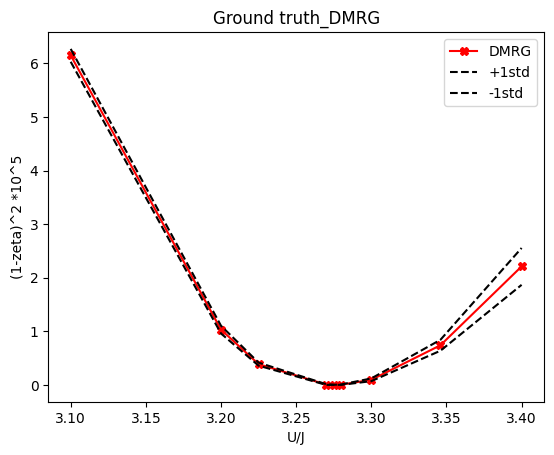

In [ ]:
#a = plt.scatter(DMRG_data[:, 0], DMRG_data[:, 1], c=DMRG_data[:, 1], cmap="jet", marker="X")
#plt.colorbar(a, orientation="vertical")
plt.plot(DMRG_data[:, 0], DMRG_data[:, 1], c="r", marker="X", label="DMRG")
plt.plot(DMRG_data[:, 0], DMRG_data[:, 1]+1*DMRG_data[:, 2], "k--", label="+1std")
plt.plot(DMRG_data[:, 0], DMRG_data[:, 1]-1*DMRG_data[:, 2], "k--", label="-1std")
plt.legend(loc="best")
#plt.xlim(3.125, 4)
plt.xlabel("U/J")
plt.ylabel("(1-zeta)^2 *10^5")
plt.title("Ground truth_DMRG")

plt.show()


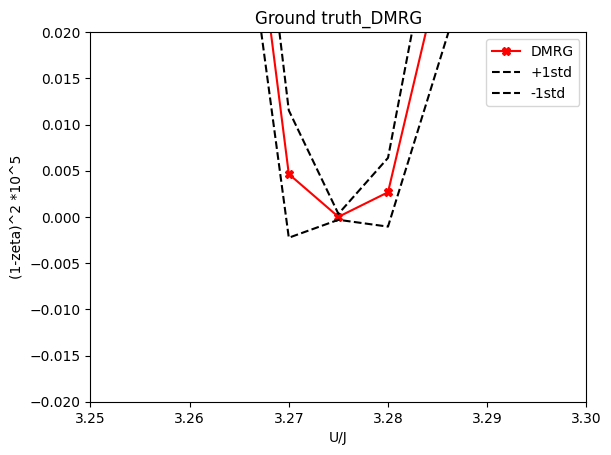

In [ ]:
#a = plt.scatter(DMRG_data[:, 0], DMRG_data[:, 1], c=DMRG_data[:, 1], cmap="jet", marker="X")
#plt.colorbar(a, orientation="vertical")
plt.plot(DMRG_data[:, 0], DMRG_data[:, 1], c="r", marker="X", label="DMRG")
plt.plot(DMRG_data[:, 0], DMRG_data[:, 1]+1*DMRG_data[:, 2], "k--", label="+1std")
plt.plot(DMRG_data[:, 0], DMRG_data[:, 1]-1*DMRG_data[:, 2], "k--", label="-1std")
plt.legend(loc="best")
plt.xlim(3.25, 3.3)
plt.ylim(-0.02, 0.02)
plt.xlabel("U/J")
plt.ylabel("(1-zeta)^2 *10^5")
plt.title("Ground truth_DMRG")

plt.show()

# Generate train and test data from qMC dataset

In [ ]:
lb = 3.1
ub = 3.4

bounds = np.array((lb, ub), dtype=float)
fidelities = np.array((1, 2))
x = np.linspace(lb, ub, 1000)
x


array([3.1       , 3.1003003 , 3.1006006 , 3.1009009 , 3.1012012 ,
       3.1015015 , 3.1018018 , 3.1021021 , 3.1024024 , 3.1027027 ,
       3.103003  , 3.1033033 , 3.1036036 , 3.1039039 , 3.1042042 ,
       3.1045045 , 3.1048048 , 3.10510511, 3.10540541, 3.10570571,
       3.10600601, 3.10630631, 3.10660661, 3.10690691, 3.10720721,
       3.10750751, 3.10780781, 3.10810811, 3.10840841, 3.10870871,
       3.10900901, 3.10930931, 3.10960961, 3.10990991, 3.11021021,
       3.11051051, 3.11081081, 3.11111111, 3.11141141, 3.11171171,
       3.11201201, 3.11231231, 3.11261261, 3.11291291, 3.11321321,
       3.11351351, 3.11381381, 3.11411411, 3.11441441, 3.11471471,
       3.11501502, 3.11531532, 3.11561562, 3.11591592, 3.11621622,
       3.11651652, 3.11681682, 3.11711712, 3.11741742, 3.11771772,
       3.11801802, 3.11831832, 3.11861862, 3.11891892, 3.11921922,
       3.11951952, 3.11981982, 3.12012012, 3.12042042, 3.12072072,
       3.12102102, 3.12132132, 3.12162162, 3.12192192, 3.12222

In [ ]:
X_train = to.from_numpy(DMRG_data[:, 0]).double()
y_train = to.from_numpy(DMRG_data[:, 1]).double()
y_train_sd = to.from_numpy(DMRG_data[:, 2]).double()
y_train = torch.stack((y_train, y_train_sd), dim=1)
test_X =to.from_numpy(x).double()
X_train.shape, y_train.shape, test_X.shape

(torch.Size([9]), torch.Size([9, 2]), torch.Size([1000]))

# Run Constraint_NoisyBO

In [ ]:
((torch.mean((y_train[:, 1])**2)))

tensor(0.0167, dtype=torch.float64)

In [ ]:
N=1
# Set the number of collocation points (quadrature points)
num_nodes = 5
train_Y_realization, train_Y_weights = get_collocation_points(y_train, num_nodes)
train_Y_realization= train_Y_realization.double()
train_Y_weights= train_Y_weights.double()
#initial_noise = ((torch.mean((y_train[:, 1])**2)))
initial_noise = torch.tensor(0.0)
optimized_lengthscale = torch.zeros(num_nodes)
optimized_output_scale = torch.zeros(num_nodes)
optimized_noise = torch.zeros(num_nodes)
y_pred_means_realization =torch.zeros(test_X.shape[0], num_nodes)
y_pred_vars_realization =torch.zeros(test_X.shape[0], num_nodes)

for j in range(0, num_nodes):
      print(f"Realization: {j+1}/{num_nodes}")
      # Fit GP for each Y realization at each collocation nodes
      optimized_lengthscale[j], optimized_output_scale[j], optimized_noise[j] = \
      optimize_hyperparameters(X_train.reshape(-1, 1), train_Y_realization[:, j].reshape(-1, 1), test_X.reshape(-1, 1), initial_noise= None, w1= 14, w2=1)
      # Calculate GP predictions for each Y realization at each collocation nodes
      means, vars = predict_phy(X_train.reshape(-1, 1), train_Y_realization[:, j].reshape(-1, 1), test_X.reshape(-1, 1), optimized_lengthscale[j], optimized_output_scale[j], noise=optimized_noise[j], w1 =14, w2=1)
      y_pred_means_realization[:, j] = means[:, 0]
      y_pred_vars_realization[:, j] = vars

      y_pred_means = torch.sum(train_Y_weights[0,:]*y_pred_means_realization, dim=1)
      y_pred_vars = torch.sum(train_Y_weights[0,:]**2*y_pred_vars_realization, dim =1)



/tmp/ipykernel_2895/3610685959.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_realization[i, :] = torch.tensor(points * torch.sqrt(torch.tensor(2.0)) * std_dev[i] + mean[i])
/tmp/ipykernel_2895/3610685959.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_weights[i, :] = torch.tensor(weights / torch.sqrt(torch.tensor(np.pi)))


Realization: 1/5
Optimized Hyperparams- LengthScale: 0.1275111734867096, Sigma: 4.86740779876709, noise: 0.0
Realization: 2/5
Optimized Hyperparams- LengthScale: 0.11000644415616989, Sigma: 3.9273228645324707, noise: 0.0
Realization: 3/5
Optimized Hyperparams- LengthScale: 0.09857171773910522, Sigma: 3.431995153427124, noise: 0.0
Realization: 4/5
Optimized Hyperparams- LengthScale: 0.09405110776424408, Sigma: 3.4081530570983887, noise: 0.0
Realization: 5/5
Optimized Hyperparams- LengthScale: 0.08978023380041122, Sigma: 3.3842315673828125, noise: 0.0


/tmp/ipykernel_2895/2604501584.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred_sd = np.sqrt(y_pred_vars)


Text(0, 0.5, '(1-Zeta)^2 x 10^5')

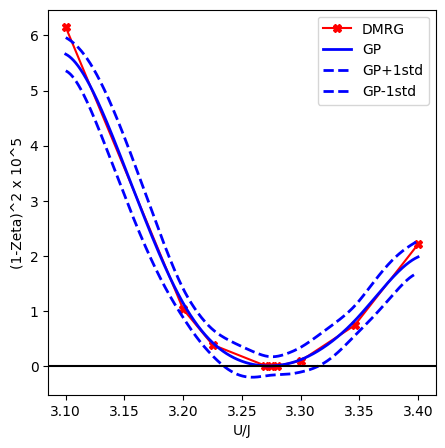

In [ ]:
from matplotlib.lines import lineStyles
y_pred_sd = np.sqrt(y_pred_vars)
Y_pred_upper = y_pred_means+(1*y_pred_sd)
Y_pred_lower = y_pred_means-(1*y_pred_sd)
_, ax = plt.subplots(1, 1, figsize=(5, 5))
#Plotting for BO exploration in GP predicted function
#ax.plot(X,true_y, c='gray', linestyle = '--', linewidth=2)
ax.plot(DMRG_data[:, 0], DMRG_data[:, 1], c="r", marker="X", label="DMRG")
ax.plot(test_X, y_pred_means.detach().numpy(), c='blue', linewidth=2, label="GP")
ax.plot(test_X, Y_pred_upper.detach().numpy(), c='blue', linestyle = '--', linewidth=2, label="GP+1std")
ax.plot(test_X, Y_pred_lower.detach().numpy(), c='blue', linestyle = '--', linewidth=2, label="GP-1std")
#ax.scatter(X_train.detach().numpy(), y_train[:,0].detach().numpy(), c='red', marker='o')
#ax.plot(DMRG_data[:, 0], DMRG_data[:, 1]+2*DMRG_data[:, 2], "k--", label="+2std")
#ax.plot(DMRG_data[:, 0], DMRG_data[:, 1]-2*DMRG_data[:, 2], "k--", label="-2std")
plt.axhline(y=0, color='black', linestyle='-')
#plt.xlim(-2.2, -2)
#plt.ylim(-0.2, 0.5)
ax.legend(loc="best")

ax.set_xlabel('U/J')
ax.set_ylabel('(1-Zeta)^2 x 10^5')

/tmp/ipykernel_2895/3966832768.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred_sd = np.sqrt(y_pred_vars)


Text(0, 0.5, '(1-Zeta)^2 x 10^5')

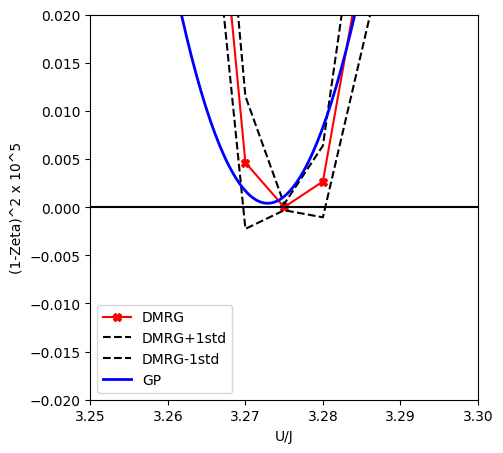

In [ ]:
from matplotlib.lines import lineStyles
y_pred_sd = np.sqrt(y_pred_vars)
Y_pred_upper = y_pred_means+(1*y_pred_sd)
Y_pred_lower = y_pred_means-(1*y_pred_sd)
_, ax = plt.subplots(1, 1, figsize=(5, 5))
#Plotting for BO exploration in GP predicted function
#ax.plot(X,true_y, c='gray', linestyle = '--', linewidth=2)
ax.plot(DMRG_data[:, 0], DMRG_data[:, 1], c="r", marker="X", label="DMRG")
ax.plot(DMRG_data[:, 0], DMRG_data[:, 1]+1*DMRG_data[:, 2], "k--", label="DMRG+1std")
ax.plot(DMRG_data[:, 0], DMRG_data[:, 1]-1*DMRG_data[:, 2], "k--", label="DMRG-1std")
ax.plot(test_X, y_pred_means.detach().numpy(), c='blue', linewidth=2, label="GP")
#ax.plot(test_X, Y_pred_upper.detach().numpy(), c='blue', linestyle = '--', linewidth=2, label="GP+1std")
#ax.plot(test_X, Y_pred_lower.detach().numpy(), c='blue', linestyle = '--', linewidth=2, label="GP-1std")
#ax.scatter(X_train.detach().numpy(), y_train[:,0].detach().numpy(), c='red', marker='o')

plt.axhline(y=0, color='black', linestyle='-')
plt.xlim(3.25, 3.3)
plt.ylim(-0.02, 0.02)
ax.legend(loc="best")

ax.set_xlabel('U/J')
ax.set_ylabel('(1-Zeta)^2 x 10^5')

In [ ]:
to.min(y_pred_means), test_X[to.argmin(y_pred_means)]

(tensor(0.0004, dtype=torch.float64), tensor(3.2730, dtype=torch.float64))

# Next sampling choice

In [ ]:
idx=[]
acq_cand, maxacq_val, acq_val = acqmanPI(y_pred_means, y_pred_vars, y_train, idx, opt="min")
val = maxacq_val
ind = np.random.choice(acq_cand)
#Augment new data with current (training) data
nextX = to.empty(1, 1)
next_feval = to.empty(1, 1)
nextX[0, 0] = x[ind]
print(nextX)


tensor([[3.2724]])


# Vanilla BO

In [ ]:
## Gp model fit
#Calling function to fit and optimizize Hyperparameter of Gaussian Process (using Adam optimizer)
# Input args- Torch arrays of training data, parameter X and objective eval Y
# Output args- Gaussian process model

gp_surro= optimize_hyperparam_trainGP(X_train, y_train[:, 0])
y_pred_means = to.empty(test_X.shape[0])
y_pred_vars = to.empty(test_X.shape[0])
for j in range(0, test_X.shape[0]):
    t_x = to.empty(1,1)
    t_x[:, 0] = test_X[j]
    t_x = t_x.double()
    with to.no_grad(), gpt.settings.max_lanczos_quadrature_iterations(32), \
          gpt.settings.fast_computations(covar_root_decomposition=False, log_prob=False, solves=True), \
          gpt.settings.max_cg_iterations(100), \
          gpt.settings.max_preconditioner_size(80), \
          gpt.settings.num_trace_samples(128):
          #Calculate posterior means and variances
        y_pred_surro = gp_surro.posterior(t_x)
        y_pred_means[j] = y_pred_surro.mean
        y_pred_vars[j] = y_pred_surro.variance



/tmp/ipykernel_2895/2604501584.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred_sd = np.sqrt(y_pred_vars)


Text(0, 0.5, '(1-Zeta)^2 x 10^5')

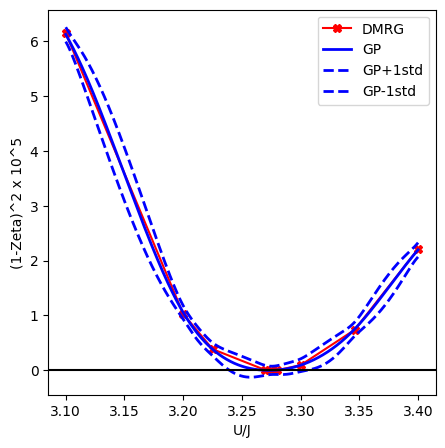

In [ ]:
from matplotlib.lines import lineStyles
y_pred_sd = np.sqrt(y_pred_vars)
Y_pred_upper = y_pred_means+(1*y_pred_sd)
Y_pred_lower = y_pred_means-(1*y_pred_sd)
_, ax = plt.subplots(1, 1, figsize=(5, 5))
#Plotting for BO exploration in GP predicted function
#ax.plot(X,true_y, c='gray', linestyle = '--', linewidth=2)
ax.plot(DMRG_data[:, 0], DMRG_data[:, 1], c="r", marker="X", label="DMRG")
ax.plot(test_X, y_pred_means.detach().numpy(), c='blue', linewidth=2, label="GP")
ax.plot(test_X, Y_pred_upper.detach().numpy(), c='blue', linestyle = '--', linewidth=2, label="GP+1std")
ax.plot(test_X, Y_pred_lower.detach().numpy(), c='blue', linestyle = '--', linewidth=2, label="GP-1std")
#ax.scatter(X_train.detach().numpy(), y_train[:,0].detach().numpy(), c='red', marker='o')
#ax.plot(DMRG_data[:, 0], DMRG_data[:, 1]+2*DMRG_data[:, 2], "k--", label="+2std")
#ax.plot(DMRG_data[:, 0], DMRG_data[:, 1]-2*DMRG_data[:, 2], "k--", label="-2std")
plt.axhline(y=0, color='black', linestyle='-')
#plt.xlim(-2.2, -2)
#plt.ylim(-0.2, 0.5)
ax.legend(loc="best")

ax.set_xlabel('U/J')
ax.set_ylabel('(1-Zeta)^2 x 10^5')

/tmp/ipykernel_2895/2345029889.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred_sd = np.sqrt(y_pred_vars)


Text(0, 0.5, '(1-Zeta)^2 x 10^5')

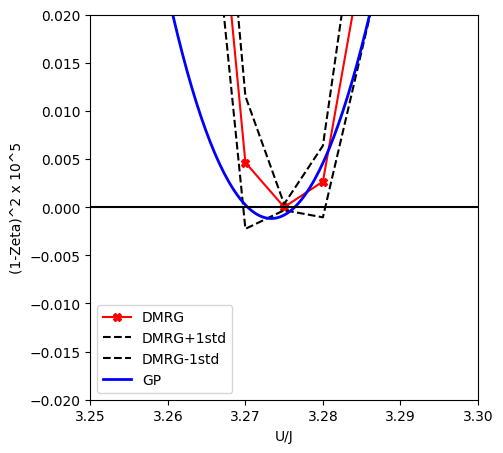

In [ ]:
from matplotlib.lines import lineStyles
y_pred_sd = np.sqrt(y_pred_vars)
Y_pred_upper = y_pred_means+(1*y_pred_sd)
Y_pred_lower = y_pred_means-(1*y_pred_sd)
_, ax = plt.subplots(1, 1, figsize=(5, 5))
#Plotting for BO exploration in GP predicted function
#ax.plot(X,true_y, c='gray', linestyle = '--', linewidth=2)
ax.plot(DMRG_data[:, 0], DMRG_data[:, 1], c="r", marker="X", label="DMRG")
ax.plot(DMRG_data[:, 0], DMRG_data[:, 1]+1*DMRG_data[:, 2], "k--", label="DMRG+1std")
ax.plot(DMRG_data[:, 0], DMRG_data[:, 1]-1*DMRG_data[:, 2], "k--", label="DMRG-1std")
ax.plot(test_X, y_pred_means.detach().numpy(), c='blue', linewidth=2, label="GP")
#ax.plot(test_X, Y_pred_upper.detach().numpy(), c='blue', linestyle = '--', linewidth=2, label="GP+1std")
#ax.plot(test_X, Y_pred_lower.detach().numpy(), c='blue', linestyle = '--', linewidth=2, label="GP-1std")
#ax.scatter(X_train.detach().numpy(), y_train[:,0].detach().numpy(), c='red', marker='o')
plt.axhline(y=0, color='black', linestyle='-')
plt.xlim(3.25, 3.3)
plt.ylim(-0.02, 0.02)
ax.legend(loc="best")

ax.set_xlabel('U/J')
ax.set_ylabel('(1-Zeta)^2 x 10^5')

In [ ]:
to.min(y_pred_means), test_X[to.argmin(y_pred_means)]

(tensor(-0.0012), tensor(3.2733, dtype=torch.float64))

In [ ]:
idx=[]
acq_cand, maxacq_val, acq_val = acqmanPI(y_pred_means, y_pred_vars, y_train, idx, opt="min")
val = maxacq_val
ind = np.random.choice(acq_cand)
#Augment new data with current (training) data
nextX = to.empty(1, 1)
next_feval = to.empty(1, 1)
nextX[0, 0] = x[ind]
print(nextX)


tensor([[3.2721]])


In [ ]:
DMRG_data

array([[3.100e+00, 6.150e+00, 1.200e-01],
       [3.200e+00, 1.030e+00, 7.220e-02],
       [3.225e+00, 3.860e-01, 2.820e-02],
       [3.270e+00, 4.640e-03, 6.890e-03],
       [3.275e+00, 9.530e-06, 3.210e-04],
       [3.280e+00, 2.670e-03, 3.720e-03],
       [3.300e+00, 9.340e-02, 2.540e-02],
       [3.346e+00, 7.380e-01, 1.020e-01],
       [3.400e+00, 2.210e+00, 3.440e-01]])